## Paul Ng
## MSDS 689-01
## Group 3
## Group Assignment Task 3

In [1]:
from pyspark import SparkConf, SparkContext
import pyspark

sc = pyspark.SparkContext(appName="paul").getOrCreate()
sc.setLogLevel("ERROR")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/12/02 19:04:43 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [2]:
import argparse

parser = argparse.ArgumentParser()
parser.add_argument(
    "--is-local",
    type=str,
    default="true",
    help="Whether running in local mode",
)

args, unknown = parser.parse_known_args()
is_local = args.is_local.lower() == "true"
if is_local:
    prefix = "../data/processed/merged"
else:
    prefix = "gs://msds-694-cohort-14-3/data"

print(f"Is local environment: {is_local}")

num_csv_path = f"{prefix}/num_2020.csv"
pre_csv_path = f"{prefix}/pre_2020.csv"
sub_csv_path = f"{prefix}/sub_2020.csv"
tag_csv_path = f"{prefix}/tag_2020.csv"

print(f"Num CSV path: {num_csv_path}")
print(f"Pre CSV path: {pre_csv_path}")
print(f"Sub CSV path: {sub_csv_path}")
print(f"Tag CSV path: {tag_csv_path}")

num_rdd = sc.textFile(num_csv_path)
pre_rdd = sc.textFile(pre_csv_path)
sub_rdd = sc.textFile(sub_csv_path)
tag_rdd = sc.textFile(tag_csv_path)

# print size of each RDD
print(f"Num RDD size: {num_rdd.count()}")
print(f"Pre RDD size: {pre_rdd.count()}")
print(f"Sub RDD size: {sub_rdd.count()}")
print(f"Tag RDD size: {tag_rdd.count()}")

Is local environment: True
Num CSV path: ../data/processed/merged/num_2020.csv
Pre CSV path: ../data/processed/merged/pre_2020.csv
Sub CSV path: ../data/processed/merged/sub_2020.csv
Tag CSV path: ../data/processed/merged/tag_2020.csv


Num RDD size: 11493263
Pre RDD size: 2746310
Sub RDD size: 24940
Tag RDD size: 298803


In [3]:
#num_rdd.glom().collect()

#### Splitting the data

In [4]:
num_rdd = num_rdd.map(lambda x: x.split(","))

#### Removing the first row in the dataset (header)

In [5]:
header = num_rdd.first()
num_data = num_rdd.filter(lambda line: line != header)

In [6]:
#num_data.collect()

#### Metrics for Company Net Earnings

Based on an exploration of the Financial Statement Data Sets, to determine the net income of a given company reported quarterly, the tags "NetIncomeLoss" and "ProfitLoss" will be used. In the dataset, there are more specific variants of "NetIncomeLoss", including:

- NetIncomeLossAvailableToCommonStockholdersBasic

- NetIncomeLossAvailableToCommonStockholdersDiluted

- NetIncomeLossFromContinuingOperationsAvailableToCommonShareholdersBasic

- NetIncomeLossFromContinuingOperationsAvailableToCommonShareholdersDiluted

- NetIncomeLossAttributableToNoncontrollingInterest

However, these can be thought of as subcomponents of net income and thus is not all-inclusive. To explore earnings of companies, the tag "NetIncomeLoss" will be used since it represents the overall earnings for the company.

There are also Earnings Per Share (EPS) metrics in the dataset, which could be interesting to explore and compare.


In [7]:
earnings_tags = ["NetIncomeLoss", "ProfitLoss"]

#### Filtering data with "NetIncomeLoss" and "ProfitLoss" tags

The format of the num dataset is as follows:

0 = adsh

1 = tag

2 = version

3 = ddate

4 = qtrs

5 = uom

6 = segments

7 = coreg

8 = value

9 = footnote

10 = quarter

11 = year

In [8]:

earnings_rdd = (
    num_data
    .filter(lambda row: row[1] in earnings_tags)
    .filter(lambda row: row[5] == "USD")
    .filter(lambda row: row[4] == "1")
    .filter(lambda row: row[8] not in ("", "NaN", "nan"))
)


In [9]:
earnings_rdd.take(5)

[['0001572758-20-000018',
  'NetIncomeLoss',
  'us-gaap/2019',
  '20180930',
  '1',
  'USD',
  '',
  '',
  '3209000.0',
  '',
  'q1',
  '2020'],
 ['0000821026-20-000011',
  'ProfitLoss',
  'us-gaap/2019',
  '20190930',
  '1',
  'USD',
  '',
  '',
  '-5870000.0',
  '',
  'q1',
  '2020'],
 ['0001564590-20-009164',
  'NetIncomeLoss',
  'us-gaap/2019',
  '20180930',
  '1',
  'USD',
  '',
  '',
  '8997000.0',
  '',
  'q1',
  '2020'],
 ['0001628280-20-003720',
  'NetIncomeLoss',
  'us-gaap/2019',
  '20180930',
  '1',
  'USD',
  '',
  '',
  '-45120000.0',
  '',
  'q1',
  '2020'],
 ['0001061219-20-000014',
  'ProfitLoss',
  'us-gaap/2019',
  '20180630',
  '1',
  'USD',
  '',
  '',
  '687200000.0',
  '',
  'q1',
  '2020']]

In [10]:
earnings_by_filing = earnings_rdd.map(
    lambda row: (
        (row[11], row[10], row[0]),   # key: (year, quarter, adsh)
        float(row[8])                 # value: net income
    )
)

In [11]:
earnings_by_filing.take(5)

[(('2020', 'q1', '0001572758-20-000018'), 3209000.0),
 (('2020', 'q1', '0000821026-20-000011'), -5870000.0),
 (('2020', 'q1', '0001564590-20-009164'), 8997000.0),
 (('2020', 'q1', '0001628280-20-003720'), -45120000.0),
 (('2020', 'q1', '0001061219-20-000014'), 687200000.0)]

In [12]:
earnings_by_filing.count()

190017

The above is now a paired RDD, with the key being a tuple of ("year","quarter #", "adsh ID") and the value being the "net income". Using Pair RDD will allow me to use reduceByKey, to combine any duplicates.

In [13]:
earnings_by_filing = earnings_by_filing.reduceByKey(lambda x,y: x + y)

In [14]:
earnings_by_filing.count()

20415

In [15]:
profitable_companies = earnings_by_filing.map(lambda x: (
    (x[0][0], x[0][1]),
    (1 if x[1] >  0 else 0)))

#### Number of Profitable Companies

In performing this analysis for the entire dataset, I noticed that there are rows that did not follow the proper format (and I'm assuming that it's invalid). The function below ensures the rows that are used follow this proper format.

In [16]:
valid_quarters = {"q1", "q2", "q3", "q4"}

def is_valid_quarter(kv):
    (year, q), flag = kv
    return year.isdigit() and len(year) == 4 and q in valid_quarters

profitable_companies_clean = profitable_companies.filter(is_valid_quarter)

profitable_companies_clean.take(50)


[(('2020', 'q1'), 1),
 (('2020', 'q1'), 0),
 (('2020', 'q1'), 1),
 (('2020', 'q1'), 0),
 (('2020', 'q1'), 0),
 (('2020', 'q1'), 0),
 (('2020', 'q1'), 1),
 (('2020', 'q1'), 0),
 (('2020', 'q1'), 0),
 (('2020', 'q1'), 1),
 (('2020', 'q1'), 1),
 (('2020', 'q1'), 1),
 (('2020', 'q1'), 0),
 (('2020', 'q1'), 1),
 (('2020', 'q1'), 0),
 (('2020', 'q1'), 0),
 (('2020', 'q1'), 1),
 (('2020', 'q1'), 1),
 (('2020', 'q1'), 0),
 (('2020', 'q1'), 0),
 (('2020', 'q1'), 1),
 (('2020', 'q1'), 0),
 (('2020', 'q1'), 1),
 (('2020', 'q1'), 1),
 (('2020', 'q1'), 0),
 (('2020', 'q1'), 1),
 (('2020', 'q1'), 1),
 (('2020', 'q1'), 1),
 (('2020', 'q1'), 0),
 (('2020', 'q1'), 1),
 (('2020', 'q1'), 1),
 (('2020', 'q1'), 0),
 (('2020', 'q1'), 0),
 (('2020', 'q1'), 0),
 (('2020', 'q1'), 1),
 (('2020', 'q1'), 0),
 (('2020', 'q1'), 1),
 (('2020', 'q1'), 1),
 (('2020', 'q1'), 1),
 (('2020', 'q1'), 1),
 (('2020', 'q1'), 1),
 (('2020', 'q1'), 0),
 (('2020', 'q1'), 0),
 (('2020', 'q1'), 0),
 (('2020', 'q1'), 0),
 (('2020',

In [17]:
profitable_counts_by_quarter = (
    profitable_companies_clean
    .reduceByKey(lambda a, b: a + b)
)

profitable_counts_by_quarter.collect()

[(('2020', 'q2'), 2445),
 (('2020', 'q3'), 2537),
 (('2020', 'q1'), 2069),
 (('2020', 'q4'), 2665)]

In [18]:
total_counts_by_quarter = (
    profitable_companies_clean
    .map(lambda kv: (kv[0], 1))
    .reduceByKey(lambda a, b: a + b)
)

# join: (quarter, (profitable, total))
quarter_counts = profitable_counts_by_quarter.join(total_counts_by_quarter)

# (quarter, profitable, not_profitable)
quarter_summary = quarter_counts.map(
    lambda kv: (kv[0], kv[1][0], kv[1][1] - kv[1][0])
)

quarter_summary.collect()


[(('2020', 'q2'), 2445, 2917),
 (('2020', 'q3'), 2537, 3145),
 (('2020', 'q1'), 2069, 1490),
 (('2020', 'q4'), 2665, 3041)]

#### Visualization

The chart below shows a plot of counts of profitable and non-profitable companies by quarter in 2020.

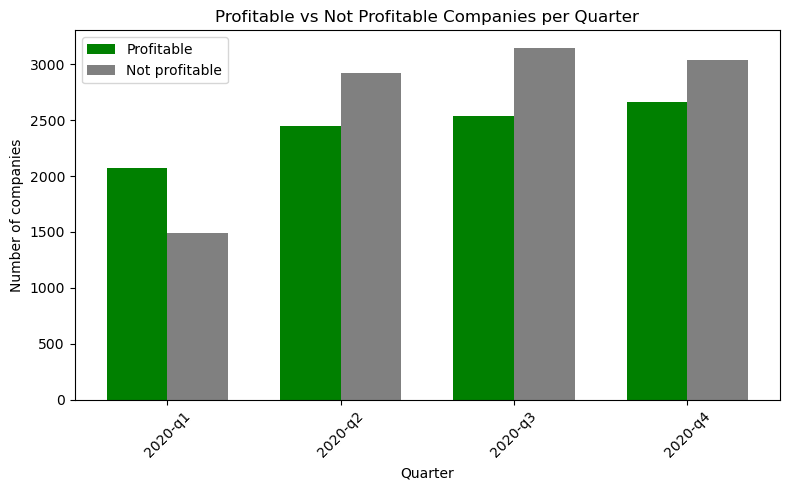

In [19]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Collect and sort
qs_list = quarter_summary.collect()

# sort by (year, quarter)
qs_list.sort(key=lambda x: (x[0][0], x[0][1]))

# 2. Build lists for plotting
quarters        = [f"{q[0]}-{q[1]}" for (q, _, _) in qs_list]  # "2020-q1"
profitable_vals = [p for (_, p, _) in qs_list]
not_profitable  = [np_ for (_, _, np_) in qs_list]

# 3. Make grouped bar chart: green = profitable, grey = not profitable
x = np.arange(len(quarters))
width = 0.35  # bar width

plt.figure(figsize=(8, 5))

plt.bar(x - width/2, profitable_vals, width,
        label="Profitable", color="green")
plt.bar(x + width/2, not_profitable, width,
        label="Not profitable", color="grey")

plt.xticks(x, quarters, rotation=45)
plt.ylabel("Number of companies")
plt.xlabel("Quarter")
plt.title("Profitable vs Not Profitable Companies per Quarter")
plt.legend()
plt.tight_layout()
plt.show()


From the chart above, it is interesting to see that for Q1, there were more profitable companies than not-profitable companies. 

On the other hand, Q2 - Q4 shows the opposite; there are more not-profitable companies than profitable companies. Year 2020 was also the year for which COVID happened and perhaps due to the lockdown measures, consumer spending, and thus company revenue and profit reduced significantly during these quarters.